In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
final_df = pd.read_csv("2012-01-2024-07-overdoses.csv")

/tmp/ipykernel_1556025/2514607087.py:1: DtypeWarning: Columns (8,11,14,19,20,37,38,39,42,43,45,46,63,64,65,66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  final_df = pd.read_csv("2012-01-2024-07-overdoses.csv")


In [8]:
final_df[final_df["DeathDate"] == "2024-07-31"]

,Unnamed: 0.1,CaseNumber,Age,Gender,Race,ResidenceType,ExperiencingHomelessness,DeathDate,DeathTime,DeathPlace,...,Shape_Length,Shape_Area,DeathAddress,EventAddress,Address,DeathAddr,EventAddr,address.death,eventaddress,address
21970,3674,2024-12138,NaN,M,Hispanic/L\natino,NaN,NaN,2024-07-31,NaN,Residence,...,124242.357098,4.052324e+08,NaN,NaN,NaN,1688 Darley Avenue,1688 Darley Avenue,"1688 Darley Avenue, Hacienda Heights","1688 Darley Avenue, Hacienda Heights","1688 Darley Ave, Hacienda Heights, California,..."
23181,4885,2024-12172,NaN,M,NaN,NaN,NaN,2024-07-31,NaN,Residence,...,82316.227776,1.396747e+08,NaN,NaN,NaN,1338 West 70th Street,NaN,"1338 West 70th Street, Los Angeles","1338 West 70th Street, Los Angeles","1338 W 70th St, Los Angeles, California, 90044"
23185,4889,2024-12433,NaN,M,White/Ca\nucasian,NaN,NaN,2024-07-31,NaN,Hospital,...,42281.163768,5.126683e+07,NaN,NaN,NaN,8700 Beverly Boulevard,NaN,"8700 Beverly Boulevard, West Hollywood","8700 Beverly Boulevard, West Hollywood","8700 Beverly Blvd, West Hollywood, California,..."


In [2]:
dmec = pd.read_csv("./pipeline_steps/input_files/2021-01-2024-01-overdoses.csv")

pr = pd.read_csv("pipeline_steps/input_files/2023-06-2024-07-overdoses.csv")

/tmp/ipykernel_1555176/3978445711.py:1: DtypeWarning: Columns (2,7,8,11,14,20,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  dmec = pd.read_csv("./pipeline_steps/input_files/2021-01-2024-01-overdoses.csv")


In [8]:
final_df = pd.concat([dmec, pr])

In [10]:
final_df = final_df.drop(columns="Unnamed: 0.1")

In [14]:
final_df["source_file"]

0       ./pipeline_steps/input_files/raw/DMEC_Deaths_0...
1       ./pipeline_steps/input_files/raw/DMEC_Deaths_0...
2       ./pipeline_steps/input_files/raw/DMEC_Deaths_0...
3       ./pipeline_steps/input_files/raw/DMEC_Deaths_0...
4       ./pipeline_steps/input_files/raw/DMEC_Deaths_0...
                              ...                        
4916    ./pipeline_steps/input_files/converted/PRA_DME...
4917    ./pipeline_steps/input_files/converted/PRA_DME...
4918    ./pipeline_steps/input_files/converted/PRA_DME...
4919    ./pipeline_steps/input_files/converted/PRA_DME...
4920    ./pipeline_steps/input_files/converted/PRA_DME...
Name: source_file, Length: 23217, dtype: object

In [17]:
final_df["DeathDate"] = final_df["DateofDeath"].combine_first(final_df["DeathDate"])

In [19]:
final_df["DeathDate"] = pd.to_datetime(final_df["DeathDate"])

In [20]:
final_df.to_csv("2012-01-2024-07-overdoses.csv")

In [22]:
# Ensure dates are sorted
final_df = final_df.sort_values("DeathDate")

# Set the date column as the index
final_df = final_df.set_index("DeathDate")

# Group by 4-week intervals and count occurrences
new_cases = final_df.resample("4W").size()

# Reset index for better readability
new_cases = new_cases.reset_index()
new_cases.columns = ["4WeekPeriod", "NewCases"]

# Display the result
print(new_cases)

    4WeekPeriod  NewCases
0    2012-01-01         3
1    2012-01-29        43
2    2012-02-26        37
3    2012-03-25        33
4    2012-04-22        38
..          ...       ...
161  2024-05-05       347
162  2024-06-02       300
163  2024-06-30       363
164  2024-07-28       105
165  2024-08-25        11

[166 rows x 2 columns]


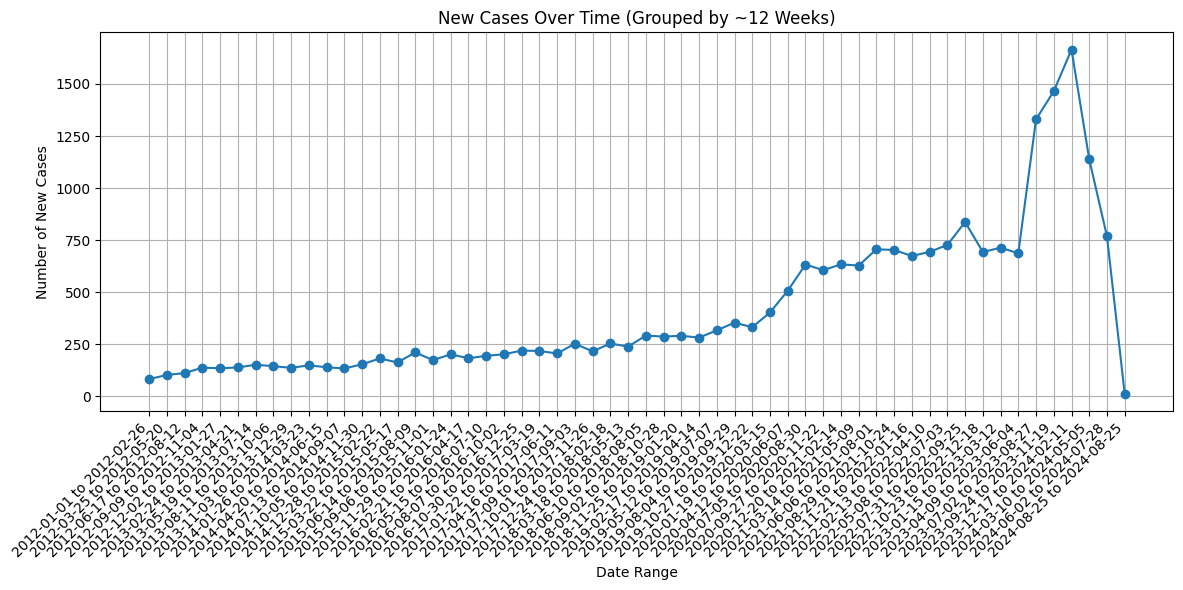

In [26]:
# Add a representative date range to each grouped period for labeling
grouped_with_dates = new_cases.groupby("GroupedPeriod").agg(
    NewCases=("NewCases", "sum"),
    StartDate=("4WeekPeriod", "min"),
    EndDate=("4WeekPeriod", "max"),
)

# Use the midpoint of the date range for labeling
grouped_with_dates["Label"] = (
    grouped_with_dates["StartDate"].dt.strftime("%Y-%m-%d")
    + " to "
    + grouped_with_dates["EndDate"].dt.strftime("%Y-%m-%d")
)

# Plot the results with dates as labels
plt.figure(figsize=(12, 6))
plt.plot(
    grouped_with_dates.index, grouped_with_dates["NewCases"], marker="o", linestyle="-"
)
plt.xticks(
    ticks=grouped_with_dates.index,
    labels=grouped_with_dates["Label"],
    rotation=45,
    ha="right",
)
plt.title("New Cases Over Time (Grouped by ~12 Weeks)")
plt.xlabel("Date Range")
plt.ylabel("Number of New Cases")
plt.grid()
plt.tight_layout()
plt.show()

Cases per source file:
                                source_file_modified  cases_in_main_df
0  ./pipeline_steps/input_files/raw/classified_PR...              9426
1  ./pipeline_steps/input_files/raw/classified_DM...              8870
2  ./pipeline_steps/input_files/converted/classif...              2056
3  ./pipeline_steps/input_files/converted/classif...              1896
4  ./pipeline_steps/input_files/converted/classif...               969
Error loading ./pipeline_steps/input_files/raw/classified_PRA_classified.csv: [Errno 2] No such file or directory: './pipeline_steps/input_files/raw/classified_PRA_classified.csv'
Error loading ./pipeline_steps/input_files/raw/classified_DMEC_classified.csv: [Errno 2] No such file or directory: './pipeline_steps/input_files/raw/classified_DMEC_classified.csv'
Error loading ./pipeline_steps/input_files/converted/classified_PRA_classified.csv: [Errno 2] No such file or directory: './pipeline_steps/input_files/converted/classified_PRA_classified.cs

In [42]:
final_df["DeathDate"]

KeyError: 'DeathDate'

In [15]:
final_df["DateofDeath"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
4916    NaN
4917    NaN
4918    NaN
4919    NaN
4920    NaN
Name: DateofDeath, Length: 23217, dtype: object

In [13]:
pra_1 = pd.read_csv(
    "./pipeline_steps/input_files/classified/PRA_DME_Cases_10-2023_to_7-2024__classified.csv"
)
ucla_rm = pd.read_csv(
    "./pipeline_steps/input_files/classified/UCLA_Romero_Ruby_Request_10.10.24_classified.csv"
)
ucla_aa = pd.read_csv(
    "./pipeline_steps/input_files/classified/UCLAAllClosedCases_classified.csv"
)

In [16]:
case_nums_1 = set(pra_1["CaseNum"])
case_nums_2 = set(ucla_rm["CaseNum"])
case_nums_3 = set(ucla_aa["CaseNum"])

case_nums_1.update(case_nums_2)

In [20]:
diff = case_nums_1.difference(case_nums_3)

In [ ]:
latest_df.drop(columns=["DeathTime"], inplace=True)

In [ ]:
duplicates = latest_df[latest_df.duplicated(subset="CaseNumber", keep=False)]
print(duplicates.head())  # Displays the first few duplicate rows

   CaseNumber       Age  Gender             Race       ResidenceType  \
0  2024-01956  37 Years    Male  Hispanic/Latino           Residence   
1  2024-01862  54 Years    Male  Hispanic/Latino                 NaN   
2  2024-01764  47 Years    Male  Hispanic/Latino  Private Residence    
3  2024-01771  49 Years  Female  Hispanic/Latino           Residence   
4  2024-01673  73 Years    Male  Hispanic/Latino          Residence`   

   ExperiencingHomelessness   DeathDate          DeathPlace      DeathCity  \
0                       NaN  2024-01-31           Residence        Burbank   
1                       NaN  2024-01-29  Private residence        Monrovia   
2                       NaN  2024-01-27  Private Residence     Pico Rivera   
3                       NaN  2024-01-27           Residence  Panorama City   
4                       NaN  2024-01-26          Residence`    Los Angeles   

  DeathZip  ...    LABEL   ShapeSTArea ShapeSTLength OBJECTID_right  ZIPCODE  \
0    91504  ...  3

In [ ]:
duplicates_sorted = duplicates.sort_values(by="CaseNumber")

In [ ]:
grouped = duplicates_sorted.groupby("CaseNumber")


# Step 4: Define a function to compare rows within each group
def find_differences(group):
    # If the group has only one row, no differences to find
    if len(group) == 1:
        return pd.DataFrame()
    else:
        # Initialize an empty DataFrame to store differences
        differences = pd.DataFrame()
        # Get all column names except 'CaseNumber'
        columns = group.columns.drop("CaseNumber")
        # Compare each column
        for column in columns:
            # Check if all values in the column are the same
            if group[column].nunique() > 1:
                # If not, include this column in differences
                differences[column] = group[column]
        # Add 'CaseNumber' to keep track of the group
        differences["CaseNumber"] = group["CaseNumber"]
        return differences


# Step 5: Apply the function to each group and collect the results
differences_list = []
for name, group in grouped:
    diff = find_differences(group)
    if not diff.empty:
        differences_list.append(diff)

# Concatenate all differences into a single DataFrame
differences_df = pd.concat(differences_list)

In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
differences_df.to_csv("./pipeline_differences.csv")

In [27]:
# Assume df is your DataFrame
# List of columns to check
columns_to_check = [
    "Methamphetamine",
    "Heroin",
    "Cocaine",
    "Fentanyl",
    "Alcohol",
    "Prescription.opioids",
    "Any Opioids",
    "Benzodiazepines",
    "Others",
    "Any Drugs",
    "Drug No Opioids",
    "EventAddress",
]


# Function to resolve duplicates based on your criteria
def resolve_duplicates(group):
    # If there's only one row, return it as is
    if len(group) == 1:
        return group

    # Step 1: Keep rows where the specified columns have '1'
    for col in columns_to_check[:-1]:  # Exclude 'EventAddress' for now
        max_value = group[col].max()
        group = group[group[col] == max_value]
        if len(group) == 1:
            return group

    # Step 2: If the values are the same, compare 'EventAddress' length
    group["EventAddress_length"] = group["EventAddress"].astype(str).str.len()
    max_length = group["EventAddress_length"].max()
    group = group[group["EventAddress_length"] == max_length]
    group = group.drop(columns="EventAddress_length")

    # Step 3: If still multiple rows, keep the first one (it doesn't matter which)
    return group.iloc[[0]]


# Apply the function to each group of duplicates
processed_df = latest_df.groupby("CaseNumber", group_keys=False).apply(
    resolve_duplicates
)

# Reset index if needed
processed_df = processed_df.reset_index(drop=True)

# Display the resulting DataFrame
print(processed_df)

       CaseNumber   Age Gender                     Race ResidenceType  \
0      2012-00007  56.0   Male  HISPANIC/LATIN AMERICAN           NaN   
1      2012-00017  51.0   Male                 FILIPINO           NaN   
2      2012-00018  50.0   Male  HISPANIC/LATIN AMERICAN           NaN   
3      2012-00071  47.0   Male  HISPANIC/LATIN AMERICAN          HOME   
4      2012-00097  29.0   Male                    BLACK          HOME   
...           ...   ...    ...                      ...           ...   
19759  2024-10450   NaN      M            Unknown/Other           NaN   
19760  2024-10451   NaN      M                      NaN           NaN   
19761  2024-10452   NaN      M          Hispanic/Latino           NaN   
19762  2024-10453   NaN      F          White/Caucasian           NaN   
19763  2024-10457   NaN      F          White/Caucasian           NaN   

       ExperiencingHomelessness   DeathDate            DeathPlace  \
0                           NaN         NaN           

/tmp/ipykernel_353430/4241692643.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  processed_df = latest_df.groupby("CaseNumber", group_keys=False).apply(


In [31]:
processed_df.to_csv("2021-01-2024-06-ods.csv")